In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "train.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "adilshamim8/predict-calorie-expenditure",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipython-input-816/2007941106.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'predict-calorie-expenditure' dataset.
First 5 records:    id     Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
0   0    male   36   189.0    82.0      26.0       101.0       41.0     150.0
1   1  female   64   163.0    60.0       8.0        85.0       39.7      34.0
2   2  female   51   161.0    64.0       7.0        84.0       39.8      29.0
3   3    male   20   192.0    90.0      25.0       105.0       40.7     140.0
4   4  female   38   166.0    61.0      25.0       102.0       40.6     146.0


In [ ]:
# Basic system and data handling
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities (for data preparation)
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Plot settings
plt.style.use('seaborn-v0_8')
sns.set_context("notebook")

In [ ]:
os.getcwd()

# Load dataset
# df = pd.read_csv("Energy_consumption_dataset.csv") # This line is redundant as df is already loaded

# Preview first few rows
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


Ckeck Missing Values and Duplicates

In [ ]:
# Missing values count
missing_values = df.isnull().sum()

# Missing values percentage
missing_percent = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percent
})

missing_df

,Missing_Count,Missing_Percentage
id,0,0.0
Sex,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
Duration,0,0.0
Heart_Rate,0,0.0
Body_Temp,0,0.0
Calories,0,0.0


In [ ]:
# Count duplicates
duplicate_count =df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)



Total duplicate rows: 0


check Outliers

In [ ]:
outlier_info = {}

num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'id' column as it's an identifier and not a feature for outlier detection
if 'id' in num_cols:
    num_cols.remove('id')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = outlier_count

pd.DataFrame.from_dict(outlier_info, orient='index', columns=['Outlier_Count'])

,Outlier_Count
Age,0
Height,14
Weight,9
Duration,0
Heart_Rate,36
Body_Temp,14919
Calories,139


Get subset

In [ ]:
df_subset = df.sample(n=100000, random_state=42)

 Split the dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Split data (70% train, 30% test)
train_data, test_data = train_test_split(
    df_subset,
    test_size=0.30,
    random_state=42
)

# Check sizes
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

# Preview
print(train_data.head())


Train shape: (70000, 9)
Test shape: (30000, 9)
            id     Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  \
410603  410603    male   21   184.0    84.0      21.0        96.0       40.3   
235221  235221  female   27   158.0    54.0      17.0        98.0       40.3   
49013    49013    male   36   181.0    78.0      13.0        92.0       40.2   
336904  336904  female   31   172.0    72.0      12.0        82.0       40.0   
508043  508043    male   38   178.0    75.0       6.0        90.0       39.1   

        Calories  
410603      87.0  
235221      93.0  
49013       55.0  
336904      43.0  
508043      25.0  


In [ ]:
print("Total subset size:", df_subset.shape)
print("Train size:", train_data.shape)
print("Test size:", test_data.shape)

Total subset size: (100000, 9)
Train size: (70000, 9)
Test size: (30000, 9)


EDA part

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
num_vars = [
    'Age', 'Height', 'Weight',
    'Heart_Rate','Body_Temp', 'Calories', 'Duration',
]

cat_vars = ['Sex']   # add more categorical variables if available

UNIVARIATE ANALYSIS

In [ ]:
train_data[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,70000.0,41.462200,15.146792,20.0,28.0,40.0,52.0,79.0
Height,70000.0,174.653829,12.830380,126.0,164.0,174.0,185.0,217.0
Weight,70000.0,75.114571,13.993640,40.0,63.0,74.0,87.0,132.0
Heart_Rate,70000.0,95.472157,9.436141,67.0,88.0,95.0,103.0,128.0
Body_Temp,70000.0,40.037094,0.778717,37.1,39.6,40.3,40.7,41.5
Calories,70000.0,88.242386,62.345857,1.0,34.0,77.0,135.0,314.0
Duration,70000.0,15.415886,8.353528,1.0,8.0,15.0,23.0,30.0


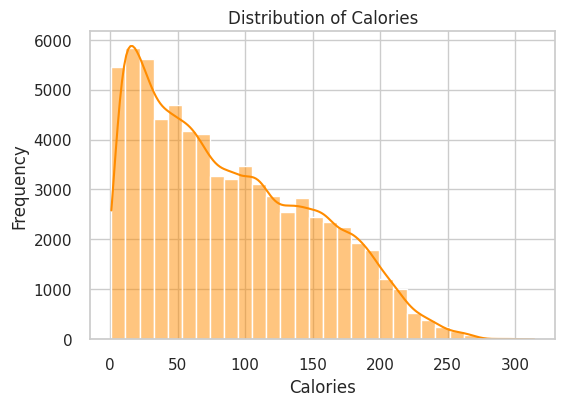

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(train_data['Calories'], kde=True, bins=30, color='darkorange')
plt.title('Distribution of Calories')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from scipy.stats import kstest
from scipy.stats import norm

# Standardize Calories
cal = train_data['Calories']
cal_std = (cal - cal.mean()) / cal.std()

ks_stat, p_value = kstest(cal_std, 'norm')

print("KS Statistic:", ks_stat)
print("p-value:", p_value)

KS Statistic: 0.08832396847816343
p-value: 0.0


In [ ]:
from scipy.stats import skew, kurtosis

print("Skewness:", skew(train_data['Calories']))


Skewness: 0.5342837650310973


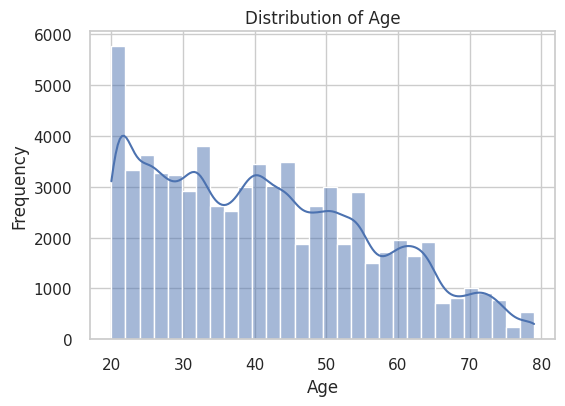

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(train_data['Age'], kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

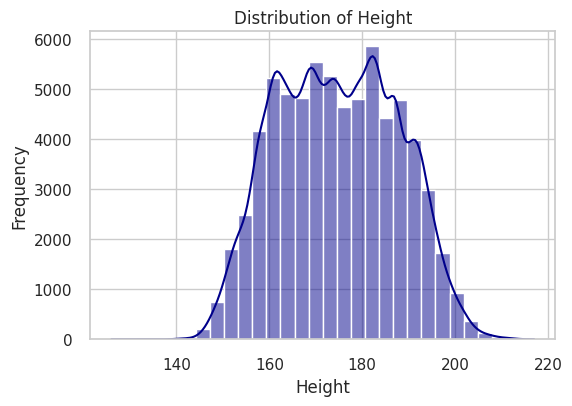

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(train_data['Height'], kde=True, bins=30,color='darkblue')
plt.title('Distribution of Height')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.show()

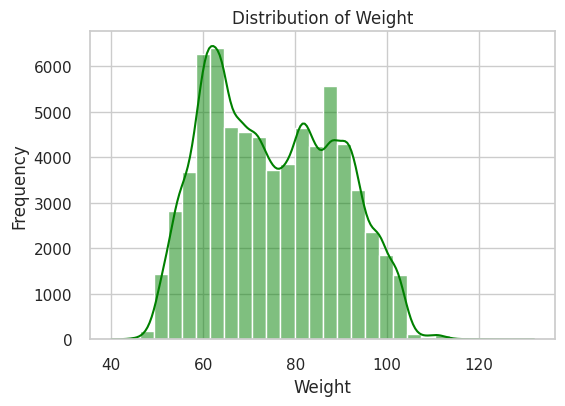

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(train_data['Weight'], kde=True, bins=30,color='green')
plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()

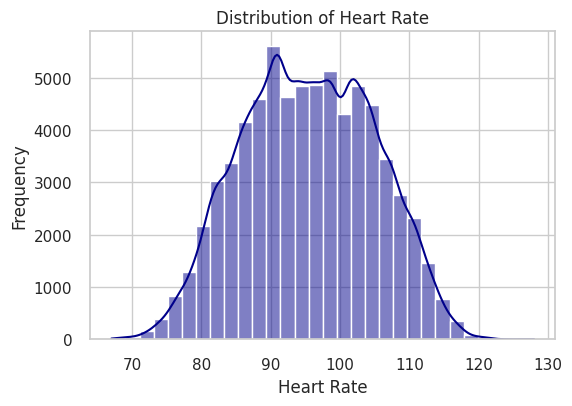

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(train_data['Heart_Rate'], kde=True, bins=30,color='darkblue')
plt.title('Distribution of Heart Rate')
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.show()

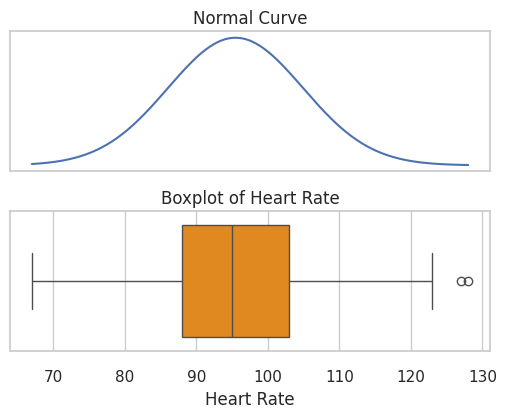

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Data
data = train_data['Heart_Rate']

# Mean and Std
mu = np.mean(data)
sigma = np.std(data)

# Create figure
fig = plt.figure(figsize=(6,4))

# ----- Top plot (Normal Curve) -----
ax1 = fig.add_axes([0.1, 0.55, 0.8, 0.35])   # [left, bottom, width, height]

x = np.linspace(min(data), max(data), 200)
y = norm.pdf(x, mu, sigma)

ax1.plot(x, y)
ax1.set_title('Normal Curve')
ax1.set_xticks([])
ax1.set_yticks([])

# ----- Bottom plot (Boxplot) -----
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.35])

sns.boxplot(x=data, color='darkorange', ax=ax2)
ax2.set_title('Boxplot of Heart Rate')
ax2.set_xlabel('Heart Rate')

plt.show()

In [ ]:
cal = train_data['Heart_Rate']
cal_std = (cal - cal.mean()) / cal.std()

ks_stat, p_value = kstest(cal_std, 'norm')

print("KS Statistic:", ks_stat)
print("p-value:", p_value)


KS Statistic: 0.050971863844571086
p-value: 1.682215750071961e-158


In [ ]:
print("Skewness:", skew(train_data['Heart_Rate']))

Skewness: -0.013895081710268415


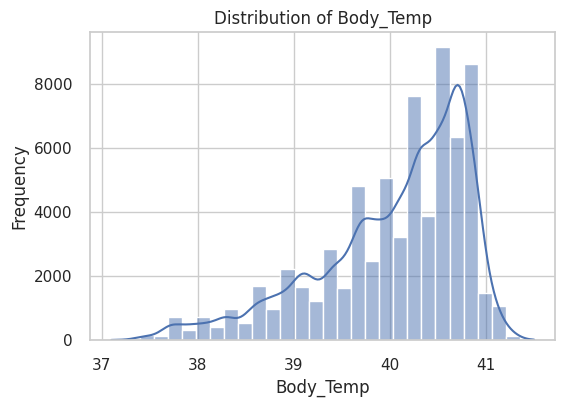

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(train_data['Body_Temp'], kde=True, bins=30)
plt.title('Distribution of Body_Temp')
plt.xlabel('Body_Temp')
plt.ylabel('Frequency')
plt.show()

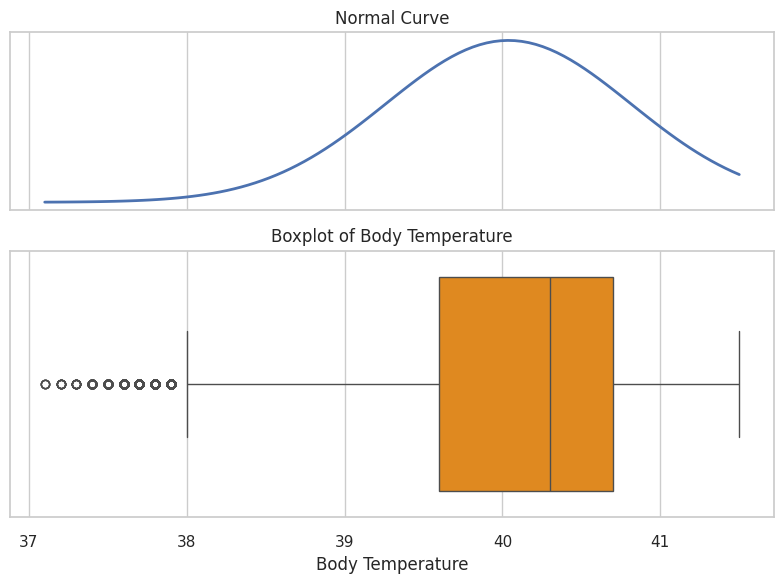

In [ ]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set the visual style to match your image
sns.set_style("whitegrid")

# 1. Create a figure with 2 subplots (Normal Curve on top, Boxplot on bottom)
# sharex=True aligns the temperature values for both plots
fig, (ax_curve, ax_box) = plt.subplots(2, 1, sharex=True, figsize=(8, 6),
                                       gridspec_kw={"height_ratios": (.4, .6)})

# --- TOP PLOT: Normal Curve ---
mu = train_data['Body_Temp'].mean()
std = train_data['Body_Temp'].std()
x = np.linspace(train_data['Body_Temp'].min(), train_data['Body_Temp'].max(), 100)
p = norm.pdf(x, mu, std)

ax_curve.plot(x, p, color='#4c72b0', linewidth=2) # Standard Seaborn blue
ax_curve.set_title('Normal Curve')
ax_curve.set_yticks([]) # Hide Y-axis numbers to match your image

# --- BOTTOM PLOT: Boxplot ---
sns.boxplot(x=train_data['Body_Temp'], color='darkorange', ax=ax_box)
ax_box.set_title('Boxplot of Body Temperature')
ax_box.set_xlabel('Body Temperature')

# Adjust layout to remove extra whitespace
plt.tight_layout()
plt.show()

In [ ]:
cal = train_data['Body_Temp']
cal_std = (cal - cal.mean()) / cal.std()

ks_stat, p_value = kstest(cal_std, 'norm')

print("KS Statistic:", ks_stat)
print("p-value:", p_value)


KS Statistic: 0.13525886554072003
p-value: 0.0


In [ ]:
print("Skewness:", skew(train_data['Body_Temp']))

Skewness: -1.0145102646863235


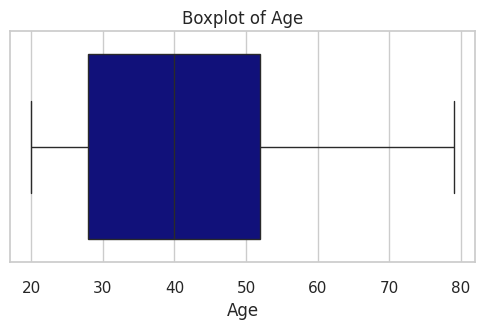

In [ ]:
plt.figure(figsize=(6,3))
sns.boxplot(x=train_data['Age'], color='darkblue')
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

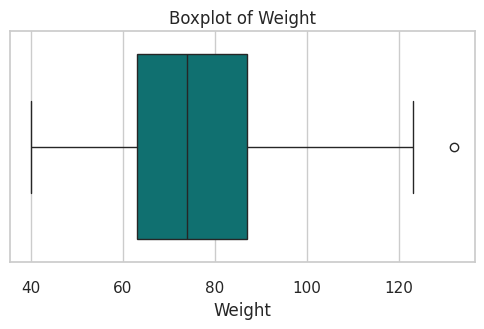

In [ ]:
plt.figure(figsize=(6,3))
sns.boxplot(x=train_data['Weight'], color='teal')
plt.title('Boxplot of Weight')
plt.xlabel('Weight')
plt.show()

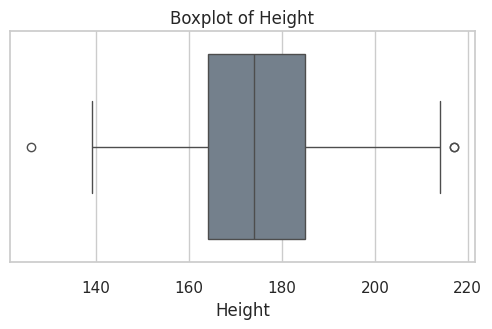

In [ ]:
plt.figure(figsize=(6,3))
sns.boxplot(x=train_data['Height'], color='slategray')
plt.title('Boxplot of Height')
plt.xlabel('Height')
plt.show()

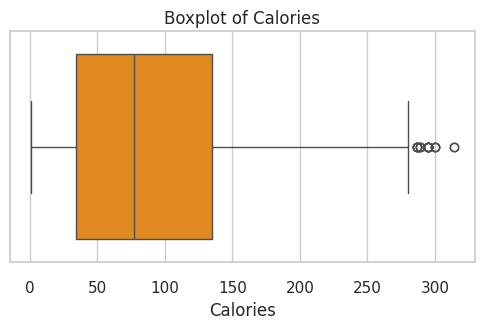

In [ ]:
plt.figure(figsize=(6,3))
sns.boxplot(x=train_data['Calories'], color='darkorange')
plt.title('Boxplot of Calories')
plt.xlabel('Calories')
plt.show()

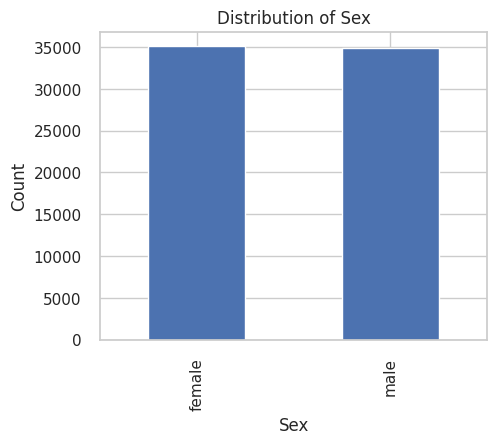

In [ ]:
for var in cat_vars:
    plt.figure(figsize=(5,4))
    train_data[var].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {var}')
    plt.ylabel('Count')
    plt.show()

 BIVARIATE ANALYSIS

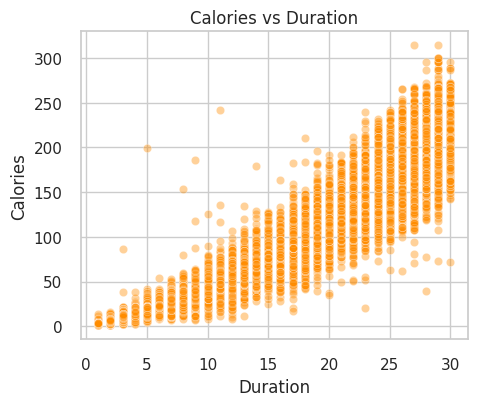

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=train_data,
    x='Duration',
    y='Calories',
    alpha=0.4,color='darkorange'
)
plt.title('Calories vs Duration')
plt.xlabel('Duration')
plt.ylabel('Calories')
plt.show()

In [ ]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(train_data['Duration'], train_data['Calories'])

print("p-value:", p_value)
print("Correlation:", corr)

p-value: 0.0
Correlation: 0.9601093023761698


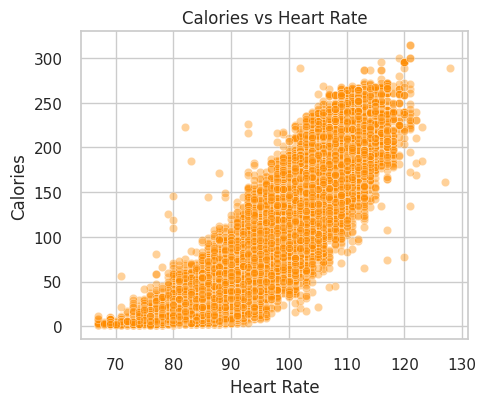

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=train_data,
    x='Heart_Rate',
    y='Calories',
    alpha=0.4,color='darkorange'
)
plt.title('Calories vs Heart Rate')
plt.xlabel('Heart Rate')
plt.ylabel('Calories')
plt.show()

In [ ]:
corr, p_value = pearsonr(train_data['Heart_Rate'], train_data['Calories'])

print("p-value:", p_value)
print("Correlation:", corr)

p-value: 0.0
Correlation: 0.9083207929613296


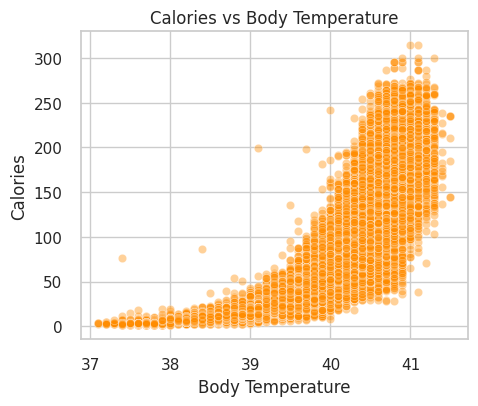

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=train_data,
    x='Body_Temp',
    y='Calories',
    alpha=0.4,color='darkorange'
)
plt.title('Calories vs Body Temperature')
plt.xlabel('Body Temperature')
plt.ylabel('Calories')
plt.show()

In [ ]:
corr, p_value = pearsonr(train_data['Body_Temp'], train_data['Calories'])

print("p-value:", p_value)
print("Correlation:", corr)

p-value: 0.0
Correlation: 0.8300922678621419


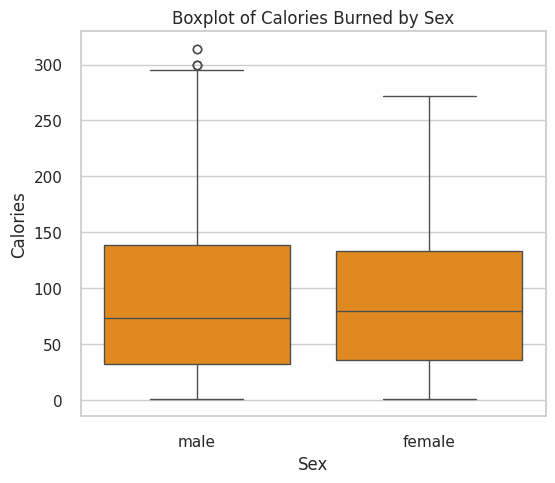

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=train_data,
    x='Sex',
    y='Calories',color='darkorange'
)

plt.title('Boxplot of Calories Burned by Sex')
plt.xlabel('Sex')
plt.ylabel('Calories')

plt.show()


In [ ]:
from scipy.stats import ttest_ind

# Separate groups
male_calories = train_data[train_data['Sex'] == 'male']['Calories']
female_calories = train_data[train_data['Sex'] == 'female']['Calories']

# Welch’s t-test (does not assume equal variance)
t_stat, p_value = ttest_ind(male_calories, female_calories, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 3.786551041319091
P-value: 0.00015288297079739044


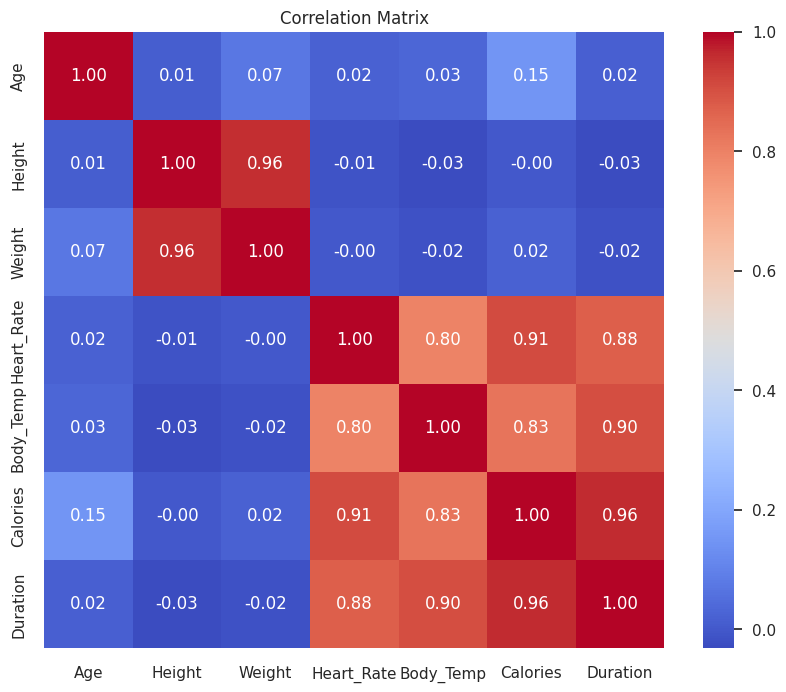

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    train_data[num_vars].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

multicolinearity

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [ ]:
# Keep only numerical columns and drop missing values
X = train_data[num_vars].dropna()

# Add constant term (required for VIF)
X_const = add_constant(X)

In [ ]:
vif_data = pd.DataFrame()
vif_data['Variable'] = X_const.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data

,Variable,VIF
0,const,16893.794182
1,Age,1.582192
2,Height,12.597138
3,Weight,12.703460
4,Heart_Rate,6.993657
5,Body_Temp,7.087227
6,Calories,31.502556
7,Duration,34.349840
